In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [57]:
# Load CSV

df =pd.read_csv("maruti_cars_multiple_cities.csv")

In [58]:
df.head()

,City,Year,Model Name,Kilometer Driven,Number of Owners,Transmission,Fuel Type,Location,Price
0,Mumbai,2010,Maruti A Star LXI,"72,583 km",2nd owner,Manual,Petrol,Pali Hill Mumbai,₹0.82 lakh
1,Mumbai,2012,Maruti A Star VXI (ABS) AT,"38,152 km",1st owner,Automatic,Petrol,Saki Naka Mumbai,₹2.44 lakh
2,Mumbai,2011,Maruti Alto LXI,"70,000 km",1st owner,Manual,Petrol,Mumbra Thane Maharashtra,₹1.21 lakh
3,Mumbai,2011,Maruti Alto LXI,"28,338 km",2nd owner,Manual,Petrol,Powai Mumbai,₹0.87 lakh
4,Mumbai,2011,Maruti Alto LXI,"80,000 km",3rd owner,Manual,Petrol,Azad Nagar Thane Maharashtra,₹0.78 lakh


In [59]:
df.shape

(780, 9)

In [7]:
df['City'].value_counts()

City
Mumbai       260
Bengaluru    260
Ahmedabad    260
Name: count, dtype: int64

In [55]:
df['Model Name'].value_counts()

Model Name
Maruti Wagon R 1.0 VXI         51
Maruti Wagon R 1.0 LXI CNG     39
Maruti Swift VXI               37
Maruti Swift Dzire VXI         32
Maruti Alto 800 LXI            30
                               ..
Maruti Swift VXI O              1
Maruti Swift ZXi Plus           1
Maruti SX4 VDI                  1
Maruti Vitara Brezza VDI        1
Maruti Wagon R Stingray VXI     1
Name: count, Length: 204, dtype: int64

In [60]:
df.head()

,City,Year,Model Name,Kilometer Driven,Number of Owners,Transmission,Fuel Type,Location,Price
0,Mumbai,2010,Maruti A Star LXI,"72,583 km",2nd owner,Manual,Petrol,Pali Hill Mumbai,₹0.82 lakh
1,Mumbai,2012,Maruti A Star VXI (ABS) AT,"38,152 km",1st owner,Automatic,Petrol,Saki Naka Mumbai,₹2.44 lakh
2,Mumbai,2011,Maruti Alto LXI,"70,000 km",1st owner,Manual,Petrol,Mumbra Thane Maharashtra,₹1.21 lakh
3,Mumbai,2011,Maruti Alto LXI,"28,338 km",2nd owner,Manual,Petrol,Powai Mumbai,₹0.87 lakh
4,Mumbai,2011,Maruti Alto LXI,"80,000 km",3rd owner,Manual,Petrol,Azad Nagar Thane Maharashtra,₹0.78 lakh


In [61]:

def clean_price(price):
    if pd.isna(price):  # Handle NaN
        return np.nan
    price = str(price).replace("₹", "").replace("$", "").replace(",", "").strip().lower()
    try:
        if "lakh" in price:
            return float(price.replace("lakh", "").strip()) * 100000
        elif "cr" in price:
            return float(price.replace("cr", "").strip()) * 10000000
        else:
            return float(price)
    except:
        return np.nan

# Apply cleaning
df["Price"] = df["Price"].apply(clean_price).round().astype("Int64")  # keep nullable int


In [62]:
df.head()

,City,Year,Model Name,Kilometer Driven,Number of Owners,Transmission,Fuel Type,Location,Price
0,Mumbai,2010,Maruti A Star LXI,"72,583 km",2nd owner,Manual,Petrol,Pali Hill Mumbai,82000
1,Mumbai,2012,Maruti A Star VXI (ABS) AT,"38,152 km",1st owner,Automatic,Petrol,Saki Naka Mumbai,244000
2,Mumbai,2011,Maruti Alto LXI,"70,000 km",1st owner,Manual,Petrol,Mumbra Thane Maharashtra,121000
3,Mumbai,2011,Maruti Alto LXI,"28,338 km",2nd owner,Manual,Petrol,Powai Mumbai,87000
4,Mumbai,2011,Maruti Alto LXI,"80,000 km",3rd owner,Manual,Petrol,Azad Nagar Thane Maharashtra,78000


In [63]:


def clean_km(km):
    if pd.isna(km):  # handle NaN
        return np.nan
    km = str(km).lower().replace("km", "").replace(",", "").strip()
    try:
        return int(km)
    except:
        return np.nan

df["Kilometer Driven"] = df["Kilometer Driven"].apply(clean_km).astype("Int64")


In [64]:
df["Number of Owners"] = df["Number of Owners"].str.extract(r"(\d+)").astype("Int64")


In [65]:
df.head()

,City,Year,Model Name,Kilometer Driven,Number of Owners,Transmission,Fuel Type,Location,Price
0,Mumbai,2010,Maruti A Star LXI,72583,2,Manual,Petrol,Pali Hill Mumbai,82000
1,Mumbai,2012,Maruti A Star VXI (ABS) AT,38152,1,Automatic,Petrol,Saki Naka Mumbai,244000
2,Mumbai,2011,Maruti Alto LXI,70000,1,Manual,Petrol,Mumbra Thane Maharashtra,121000
3,Mumbai,2011,Maruti Alto LXI,28338,2,Manual,Petrol,Powai Mumbai,87000
4,Mumbai,2011,Maruti Alto LXI,80000,3,Manual,Petrol,Azad Nagar Thane Maharashtra,78000


Basic Dataset Overview


In [67]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 780 entries, 0 to 779
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   City              780 non-null    object
 1   Year              780 non-null    int64 
 2   Model Name        780 non-null    object
 3   Kilometer Driven  780 non-null    Int64 
 4   Number of Owners  780 non-null    Int64 
 5   Transmission      780 non-null    object
 6   Fuel Type         780 non-null    object
 7   Location          780 non-null    object
 8   Price             780 non-null    Int64 
dtypes: Int64(3), int64(1), object(5)
memory usage: 57.3+ KB
None


In [68]:
print(df.describe())


              Year  Kilometer Driven  Number of Owners          Price
count   780.000000             780.0             780.0          780.0
mean   2016.011538      77654.529487          1.628205  395391.025641
std       3.810481      47493.303542            0.8358  216501.615695
min    2010.000000               1.0               1.0        59000.0
25%    2013.000000           41255.5               1.0       236500.0
50%    2016.000000           71711.0               1.0       356500.0
75%    2018.000000          101488.0               2.0       532250.0
max    2025.000000          310969.0               6.0      1437000.0


In [69]:
print(df.isna().sum())  # check missing values

City                0
Year                0
Model Name          0
Kilometer Driven    0
Number of Owners    0
Transmission        0
Fuel Type           0
Location            0
Price               0
dtype: int64


In [75]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")


In [76]:

plt.rcParams["font.family"] = "Nirmala UI"   # works well on Windows
# Or: "Mangal", "Arial Unicode MS", "DejaVu Sans" (Linux/Mac friendly)

df["Location"] = df["Location"].str.encode("ascii", "ignore").str.decode("ascii") 


Location
Akshayanagar Bengaluru Karnataka         1437000.0
Anchepalya Bengaluru                     1000000.0
Garvebhavi Palya Bengaluru                993000.0
State Bank Of India Colony Bengaluru      975000.0
Narmada Vasahat Sanand Gujarat            968000.0
                                           ...    
Modasar Bavla                              79000.0
Azad Nagar Thane Maharashtra               78000.0
Mahadev Nagar Tekra Ahmedabad Gujarat      67000.0
Nava Vadaj Ahmedabad                       65000.0
Ellisbridge Ahmedabad Gujarat              59000.0
Name: Price, Length: 431, dtype: Float64


<Axes: title={'center': 'Average Car Price by City'}, xlabel='Location'>

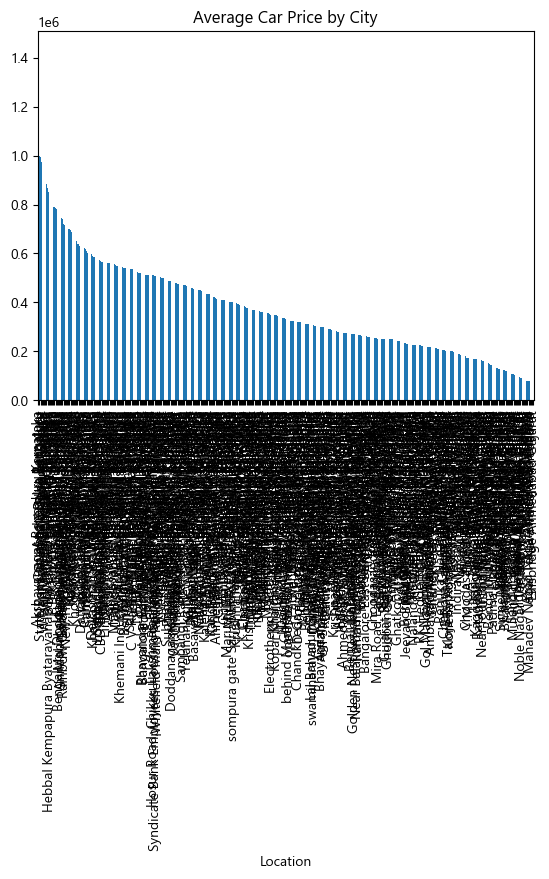

In [77]:
avg_price_city = df.groupby("Location")["Price"].mean().sort_values(ascending=False)
print(avg_price_city)
avg_price_city.plot(kind="bar", title="Average Car Price by City")

2. Average Price by City

<Axes: title={'center': 'Average Price by Year of Manufacture'}, xlabel='Year'>

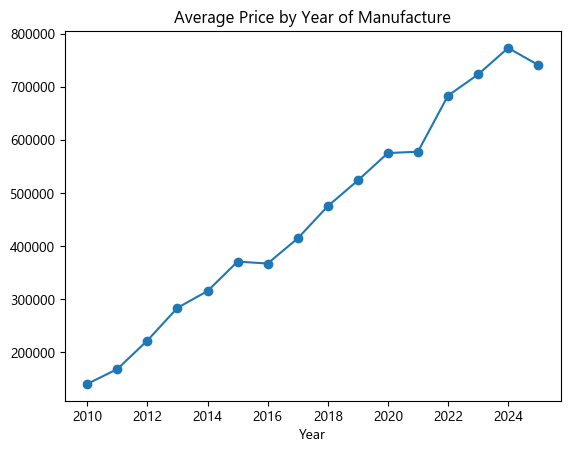

In [78]:
avg_price_year = df.groupby("Year")["Price"].mean()
avg_price_year.plot(kind="line", marker="o", title="Average Price by Year of Manufacture")


<Axes: title={'center': 'Fuel Type Distribution'}, ylabel='count'>

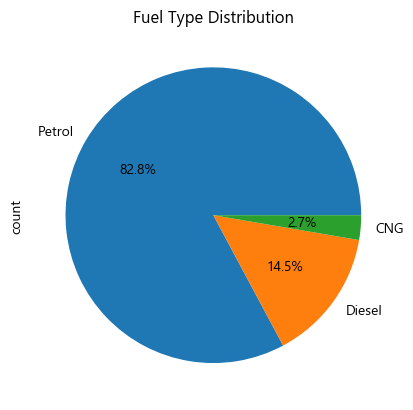

In [79]:
fuel_counts = df["Fuel Type"].value_counts()
fuel_counts.plot(kind="pie", autopct="%1.1f%%", title="Fuel Type Distribution")


<Axes: title={'center': 'Transmission Distribution'}, xlabel='Transmission'>

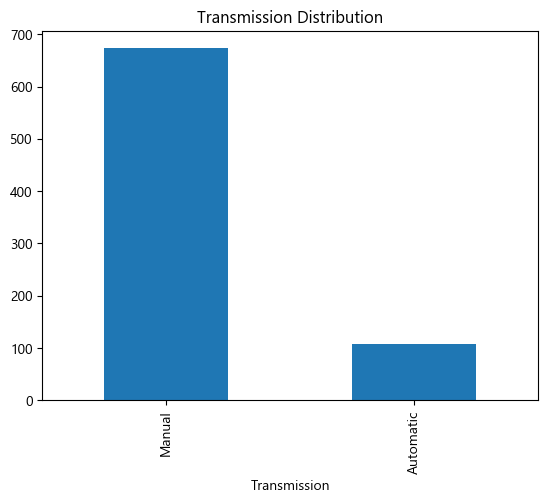

In [80]:
transmission_counts = df["Transmission"].value_counts()
transmission_counts.plot(kind="bar", title="Transmission Distribution")


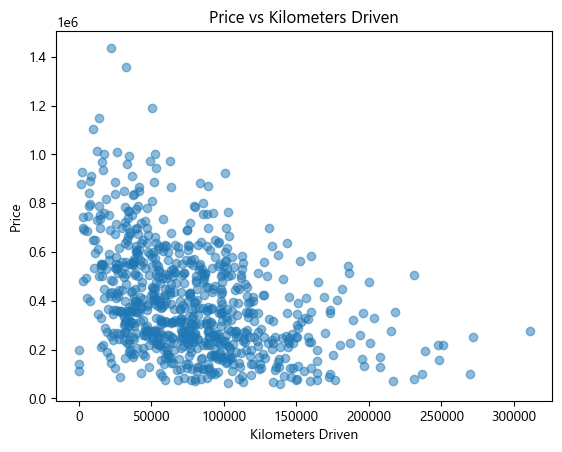

In [81]:

plt.scatter(df["Kilometer Driven"], df["Price"], alpha=0.5)
plt.xlabel("Kilometers Driven")
plt.ylabel("Price")
plt.title("Price vs Kilometers Driven")
plt.show()


<Axes: title={'center': 'Average Price by Number of Owners'}, xlabel='Number of Owners'>

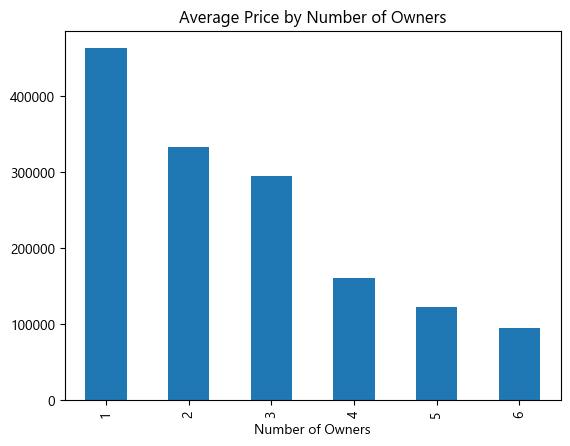

In [82]:
avg_price_owners = df.groupby("Number of Owners")["Price"].mean()
avg_price_owners.plot(kind="bar", title="Average Price by Number of Owners")


<Axes: title={'center': 'Top 10 Popular Car Models'}, xlabel='Model Name'>

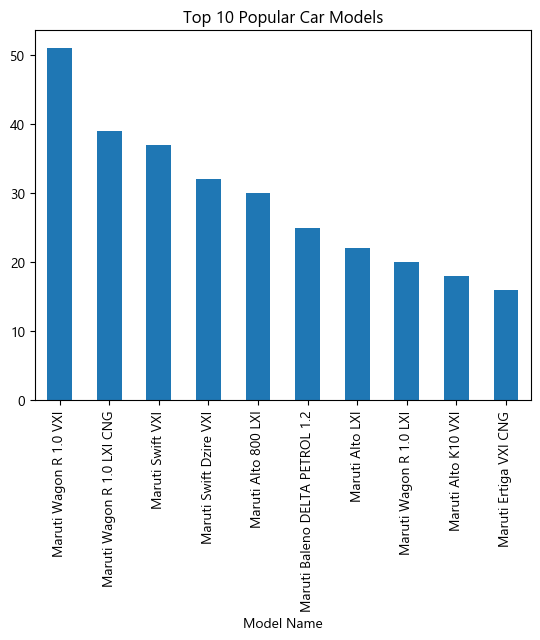

In [84]:
top_models = df["Model Name"].value_counts().head(10)
top_models.plot(kind="bar", title="Top 10 Popular Car Models")


In [87]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create pivot (avg price by City & Fuel Type)
pivot = df.pivot_table(
    index="City", 
    columns="Fuel Type", 
    values="Price", 
    aggfunc="mean"
)

# Convert to numeric (ignore errors if <NA>)
pivot = pivot.apply(pd.to_numeric, errors="coerce")

# Plot heatmap
plt.figure(figsize=(8,5))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Average Price by City & Fuel Type")
plt.show()


TypeError: float() argument must be a string or a real number, not 'NAType'

<Figure size 800x500 with 0 Axes>